In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load UCLA binary logistic regression dataset

url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

df = pd.read_stata(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [6]:
# Display information about the dataset

print("Dataset Information:")
print("--------------------")

df.info()

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [7]:
# Check dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 400
Number of columns: 4

Column names:
['admit', 'gre', 'gpa', 'rank']


In [8]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [9]:
# Check duplicate records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [10]:
# Descriptive statistics

df.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.000000
mean,0.317500,587.700012,3.389900,2.485000
std,0.466087,115.516663,0.380567,0.944462
min,0.000000,220.000000,2.260000,1.000000
25%,0.000000,520.000000,3.130000,2.000000
50%,0.000000,580.000000,3.395000,2.000000
75%,1.000000,660.000000,3.670000,3.000000
max,1.000000,800.000000,4.000000,4.000000


In [11]:
print("Mean GRE:", df['gre'].mean())
print("Mean GPA:", df['gpa'].mean())
print("Mean Rank:", df['rank'].mean())
print("Admission Rate:", df['admit'].mean())

Mean GRE: 587.7
Mean GPA: 3.3899
Mean Rank: 2.485
Admission Rate: 0.3175


In [12]:
# Frequency of admission outcomes

print(df['admit'].value_counts())

print("\nAdmission proportions:")
print(df['admit'].value_counts(normalize=True))

admit
0.0    273
1.0    127
Name: count, dtype: int64

Admission proportions:
admit
0.0    0.6825
1.0    0.3175
Name: proportion, dtype: float64


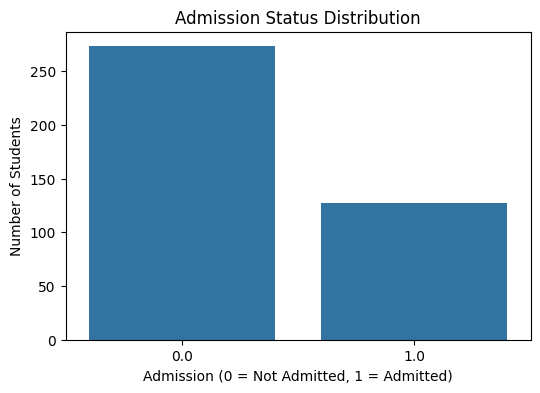

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='admit', data=df)

plt.title("Admission Status Distribution")
plt.xlabel("Admission (0 = Not Admitted, 1 = Admitted)")
plt.ylabel("Number of Students")

plt.show()

In [14]:
print("Number of students from each institution rank:")
print(df['rank'].value_counts().sort_index())

Number of students from each institution rank:
rank
1.0     61
2.0    151
3.0    121
4.0     67
Name: count, dtype: int64


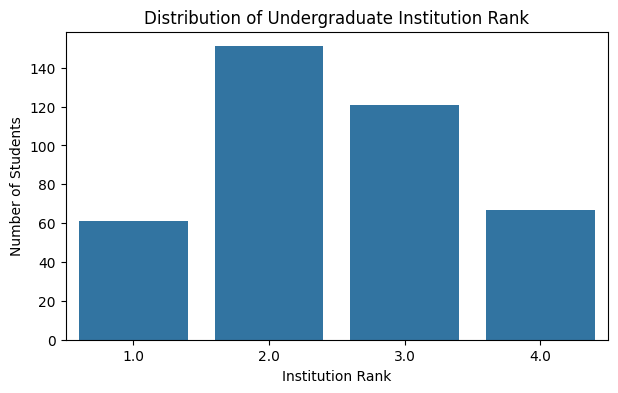

In [15]:
plt.figure(figsize=(7,4))

sns.countplot(x='rank', data=df)

plt.title("Distribution of Undergraduate Institution Rank")
plt.xlabel("Institution Rank")
plt.ylabel("Number of Students")

plt.show()

In [16]:
# Cross-tabulation

rank_admit = pd.crosstab(df['rank'], df['admit'])

print(rank_admit)

admit  0.0  1.0
rank           
1.0     28   33
2.0     97   54
3.0     93   28
4.0     55   12


In [17]:
admission_by_rank = df.groupby('rank')['admit'].mean() * 100

print("Admission percentage by institution rank:")
print(admission_by_rank)

Admission percentage by institution rank:
rank
1.0    54.098362
2.0    35.761589
3.0    23.140495
4.0    17.910448
Name: admit, dtype: float32


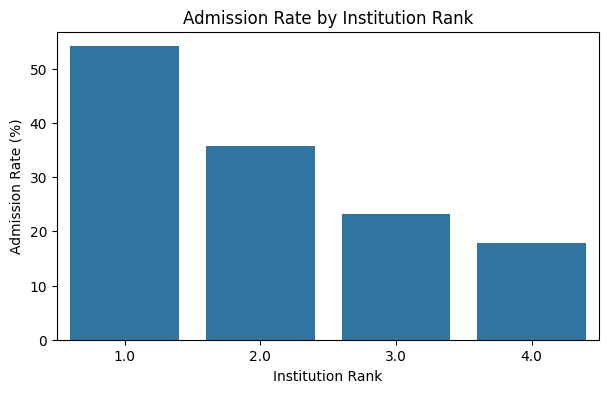

In [18]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=admission_by_rank.index,
    y=admission_by_rank.values
)

plt.title("Admission Rate by Institution Rank")
plt.xlabel("Institution Rank")
plt.ylabel("Admission Rate (%)")

plt.show()

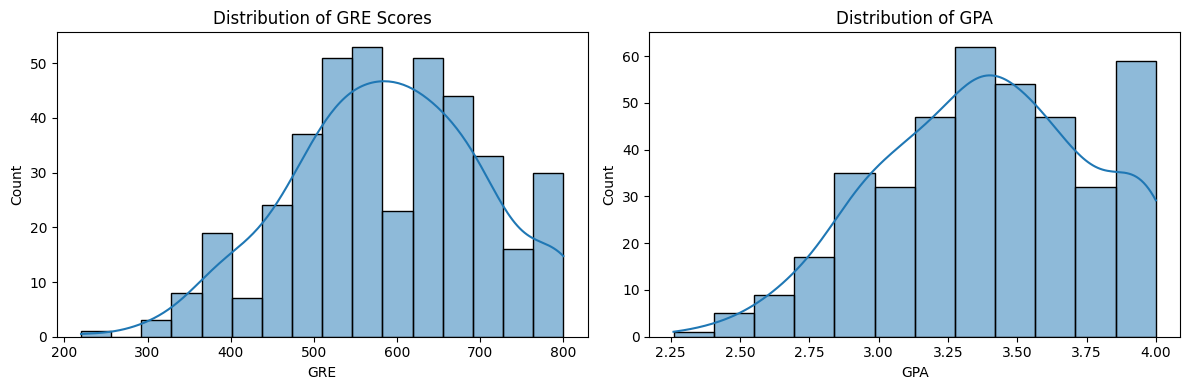

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['gre'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of GRE Scores")
axes[0].set_xlabel("GRE")

sns.histplot(df['gpa'], kde=True, ax=axes[1])
axes[1].set_title("Distribution of GPA")
axes[1].set_xlabel("GPA")

plt.tight_layout()
plt.show()

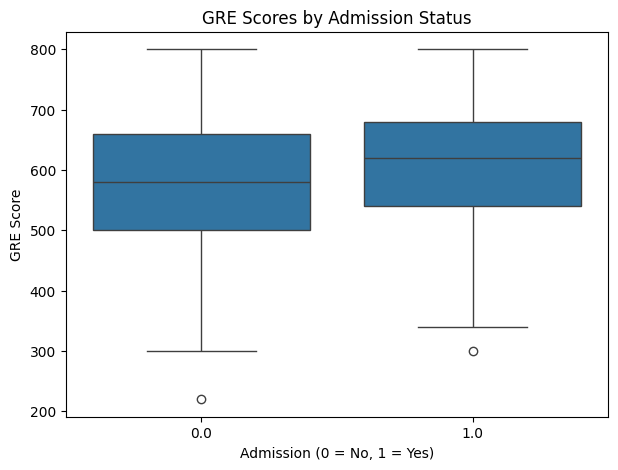

In [20]:
plt.figure(figsize=(7,5))

sns.boxplot(x='admit', y='gre', data=df)

plt.title("GRE Scores by Admission Status")
plt.xlabel("Admission (0 = No, 1 = Yes)")
plt.ylabel("GRE Score")

plt.show()

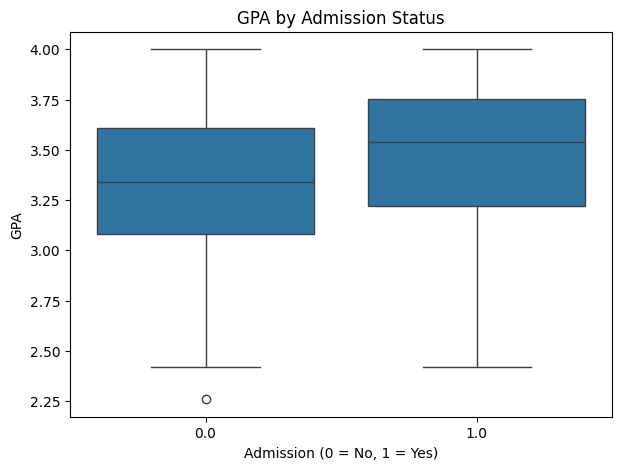

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(x='admit', y='gpa', data=df)

plt.title("GPA by Admission Status")
plt.xlabel("Admission (0 = No, 1 = Yes)")
plt.ylabel("GPA")

plt.show()

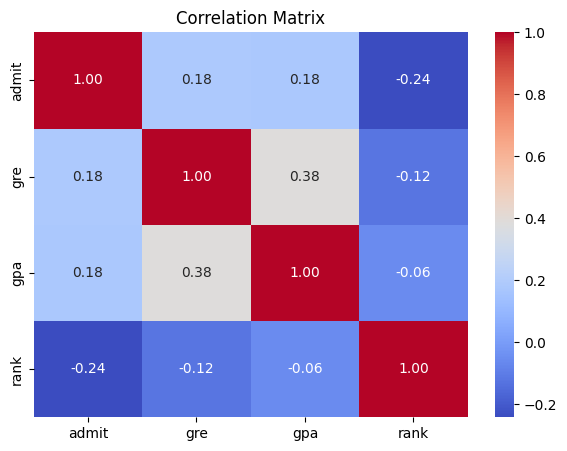

In [22]:
plt.figure(figsize=(7,5))

corr = df[['admit', 'gre', 'gpa', 'rank']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [23]:
# Logistic Regression Model
# C(rank) treats institution rank as a categorical variable

model = smf.logit(
    'admit ~ gre + gpa + C(rank)',
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Mon, 21 Sep 2026   Pseudo R-squ.:                 0.08292
Time:                        05:24:31   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2.0]   

In [24]:
# Calculate odds ratios

odds_ratios = np.exp(model.params)

print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
Intercept         0.018500
C(rank)[T.2.0]    0.508931
C(rank)[T.3.0]    0.261792
C(rank)[T.4.0]    0.211938
gre               1.002267
gpa               2.234545
dtype: float64


In [25]:
# Odds ratio table

odds_table = pd.DataFrame({
    'Coefficient': model.params,
    'Odds Ratio': np.exp(model.params),
    'P-value': model.pvalues,
    'Lower CI': np.exp(model.conf_int()[0]),
    'Upper CI': np.exp(model.conf_int()[1])
})

odds_table

,Coefficient,Odds Ratio,P-value,Lower CI,Upper CI
Intercept,-3.989979,0.018500,0.000465,0.001981,0.172783
C(rank)[T.2.0],-0.675443,0.508931,0.032829,0.273692,0.946358
C(rank)[T.3.0],-1.340204,0.261792,0.000104,0.133055,0.515089
C(rank)[T.4.0],-1.551464,0.211938,0.000205,0.093443,0.480692
gre,0.002264,1.002267,0.038465,1.000120,1.004418
gpa,0.804038,2.234545,0.015388,1.166122,4.281877


In [26]:
# Display p-values

print("P-values:")
print(model.pvalues)

P-values:
Intercept         0.000465
C(rank)[T.2.0]    0.032829
C(rank)[T.3.0]    0.000104
C(rank)[T.4.0]    0.000205
gre               0.038465
gpa               0.015388
dtype: float64


In [27]:
# Null model with intercept only

null_model = smf.logit(
    'admit ~ 1',
    data=df
).fit(disp=0)

# Likelihood ratio test

lr_stat = 2 * (model.llf - null_model.llf)
df_lr = model.df_model
p_value_lr = model.llr_pvalue

print("Likelihood Ratio Statistic:", lr_stat)
print("Degrees of Freedom:", df_lr)
print("P-value:", p_value_lr)

Likelihood Ratio Statistic: 41.45902670072604
Degrees of Freedom: 5.0
P-value: 7.578188274571569e-08


In [28]:
print("McFadden's Pseudo R²:", model.prsquared)

McFadden's Pseudo R²: 0.08292194794441865


In [29]:
df['predicted_probability'] = model.predict(df)

df[['admit', 'gre', 'gpa', 'rank', 'predicted_probability']].head(10)

,admit,gre,gpa,rank,predicted_probability
0,0.0,380.0,3.61,3.0,0.172627
1,1.0,660.0,3.67,3.0,0.292175
2,1.0,800.0,4.00,1.0,0.738408
3,1.0,640.0,3.19,4.0,0.178385
4,0.0,520.0,2.93,4.0,0.118354
5,1.0,760.0,3.00,2.0,0.369970
6,1.0,560.0,2.98,1.0,0.419246
7,0.0,400.0,3.08,2.0,0.217003
8,1.0,540.0,3.39,3.0,0.200735
9,0.0,700.0,3.92,2.0,0.517868


In [30]:
df['predicted_class'] = (
    df['predicted_probability'] >= 0.5
).astype(int)

df[['admit', 'predicted_probability', 'predicted_class']].head(10)

,admit,predicted_probability,predicted_class
0,0.0,0.172627,0
1,1.0,0.292175,0
2,1.0,0.738408,1
3,1.0,0.178385,0
4,0.0,0.118354,0
5,1.0,0.369970,0
6,1.0,0.419246,0
7,0.0,0.217003,0
8,1.0,0.200735,0
9,0.0,0.517868,1


In [31]:
cm = confusion_matrix(
    df['admit'],
    df['predicted_class']
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[254  19]
 [ 97  30]]


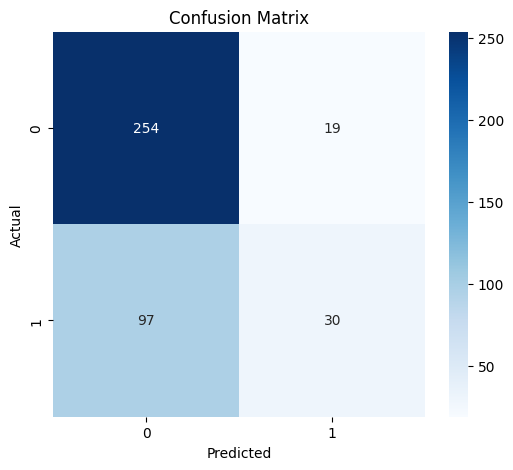

In [32]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [33]:
accuracy = accuracy_score(
    df['admit'],
    df['predicted_class']
)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.71
Accuracy (%): 71.0


In [34]:
print(
    classification_report(
        df['admit'],
        df['predicted_class']
    )
)

              precision    recall  f1-score   support

         0.0       0.72      0.93      0.81       273
         1.0       0.61      0.24      0.34       127

    accuracy                           0.71       400
   macro avg       0.67      0.58      0.58       400
weighted avg       0.69      0.71      0.66       400



In [35]:
# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    df['admit'],
    df['predicted_probability']
)

auc = roc_auc_score(
    df['admit'],
    df['predicted_probability']
)

print("AUC:", auc)

AUC: 0.6928412794554527


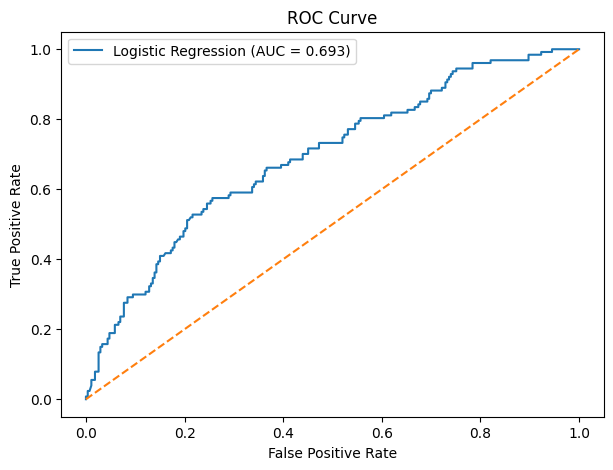

In [36]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.show()

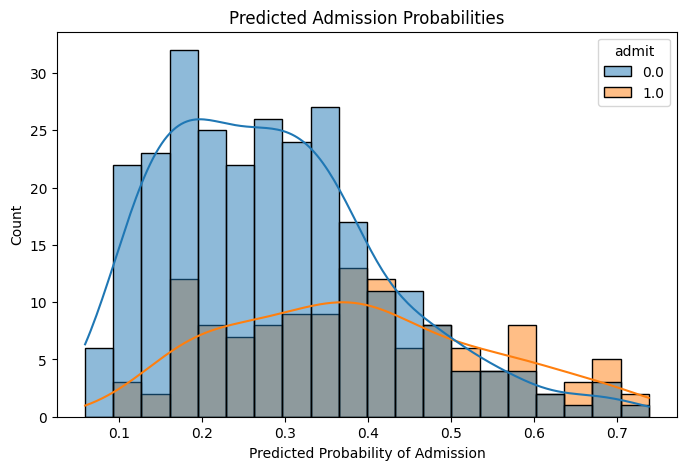

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='predicted_probability',
    hue='admit',
    bins=20,
    kde=True
)

plt.title("Predicted Admission Probabilities")
plt.xlabel("Predicted Probability of Admission")
plt.ylabel("Count")

plt.show()

In [38]:
new_student = pd.DataFrame({
    'gre': [700],
    'gpa': [3.8],
    'rank': [1]
})

probability = model.predict(new_student)[0]

print("Predicted probability of admission:", probability)

if probability >= 0.5:
    print("Predicted outcome: ADMITTED")
else:
    print("Predicted outcome: NOT ADMITTED")

Predicted probability of admission: 0.6571144964005111
Predicted outcome: ADMITTED


In [39]:
new_student = pd.DataFrame({
    'gre': [550],
    'gpa': [3.2],
    'rank': [4]
})

probability = model.predict(new_student)[0]

print("Predicted probability:", probability)

Predicted probability: 0.1514737818855878


In [40]:
print("Logistic Regression Coefficients:")
print(model.params)

Logistic Regression Coefficients:
Intercept        -3.989979
C(rank)[T.2.0]   -0.675443
C(rank)[T.3.0]   -1.340204
C(rank)[T.4.0]   -1.551464
gre               0.002264
gpa               0.804038
dtype: float64
